# Task 4: Classification with Logistic Regression

## Objective
The objective of this task is to build a binary classification model using Logistic Regression. The model will be trained on the Breast Cancer Wisconsin dataset to predict whether a tumor is malignant or benign based on various medical features.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

## Loading the Dataset

The Breast Cancer Wisconsin dataset is loaded from Scikit-learn. This dataset contains features computed from breast cancer cell nuclei and a target variable indicating whether the tumor is malignant or benign.

In [4]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Feature Shape: (569, 30)
Target Shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Splitting the Data

The dataset is divided into training and testing sets. The model learns patterns from the training data and is evaluated on unseen testing data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 455
Testing Samples: 114


## Training Logistic Regression Model

Logistic Regression is a classification algorithm that predicts the probability of a data point belonging to a particular class. It uses the sigmoid function to convert predictions into probabilities between 0 and 1.

In [6]:
model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Evaluating the Model

The model is evaluated using a confusion matrix, precision, recall, and ROC-AUC score. These metrics help measure classification performance.

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



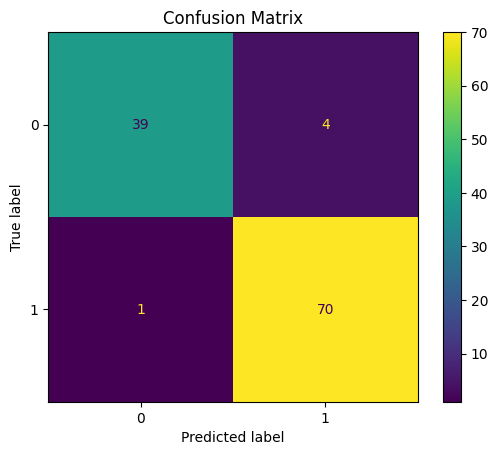

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

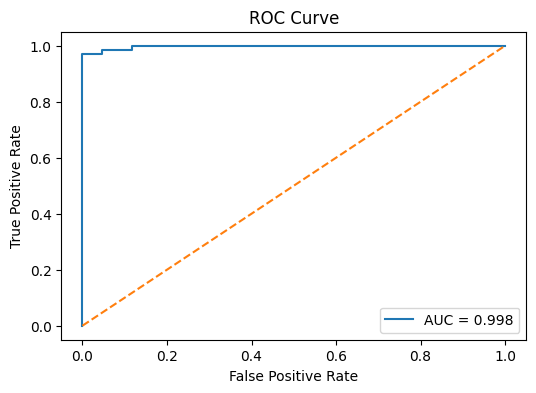

ROC-AUC Score: 0.9977071732721913


In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc_score)

## Understanding the Sigmoid Function

The sigmoid function transforms any real-valued input into a value between 0 and 1. Logistic Regression uses this function to estimate probabilities for binary classification tasks.

A probability close to 1 indicates a higher likelihood of belonging to the positive class, while a probability close to 0 indicates the negative class.

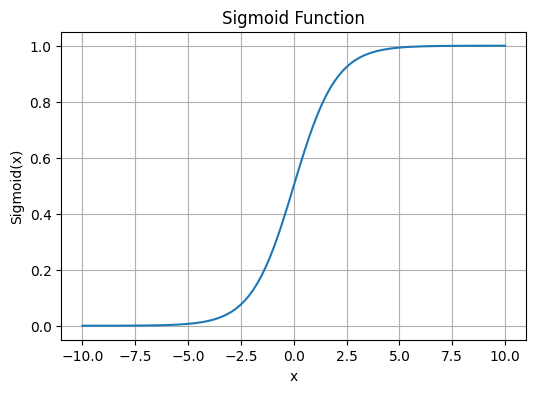

In [10]:
x = np.linspace(-10, 10, 100)

sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(6,4))
plt.plot(x, sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid(True)
plt.show()

## Conclusion

In this task, a Logistic Regression model was developed for binary classification using the Breast Cancer Wisconsin dataset. The model was trained, evaluated using multiple metrics, and visualized through a confusion matrix, ROC curve, and sigmoid function. The results demonstrate the effectiveness of Logistic Regression for binary classification problems.